# Bike Demand Forecasting

This notebook explores bike rental demand patterns and builds time-aware regression models using temporal, seasonal, and weather-based features.

## Problem Statement

The goal of this project is to predict bike rental demand using historical timestamp and weather-related variables.

Main questions:
- Can temporal and weather features explain short-term bike demand?
- Do lag and rolling features improve forecasting performance?
- Which features are most important for demand prediction?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Data

In [2]:
df = pd.read_csv("bike+sharing+dataset/hour.csv")
print(df.shape)
df.head()

(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data Cleaning

In [3]:
df["dteday"] = pd.to_datetime(df["dteday"])
df["datetime"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")

print(df.info())
print(df.isnull().sum())
print("Duplicated rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

## Feature Engineering

In [4]:
df["year"] = df["dteday"].dt.year
df["month"] = df["dteday"].dt.month
df["day"] = df["dteday"].dt.day
df["hour"] = df["hr"]
df["weekday"] = df["datetime"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

df = df.sort_values("datetime").copy()
df["lag_1"] = df["cnt"].shift(1)
df["lag_24"] = df["cnt"].shift(24)
df["lag_168"] = df["cnt"].shift(168)
df["rolling_mean_24"] = df["cnt"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["cnt"].shift(1).rolling(24).std()

df = df.dropna().copy()
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,datetime,year,month,day,hour,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
168,169,2011-01-08,1,0,1,7,0,5,0,2,0.16,0.1818,0.74,0.1045,1,8,9,2011-01-08 07:00:00,2011,1,8,7,1,2.0,84.0,16.0,63.208333,55.844488
169,170,2011-01-08,1,0,1,8,0,5,0,3,0.16,0.1818,0.93,0.1045,0,15,15,2011-01-08 08:00:00,2011,1,8,8,1,9.0,210.0,40.0,60.083333,56.721989
170,171,2011-01-08,1,0,1,9,0,5,0,3,0.16,0.1818,0.93,0.1045,0,20,20,2011-01-08 09:00:00,2011,1,8,9,1,15.0,134.0,32.0,51.958333,47.536237
171,172,2011-01-08,1,0,1,10,0,5,0,2,0.18,0.1970,0.80,0.1642,5,56,61,2011-01-08 10:00:00,2011,1,8,10,1,20.0,63.0,13.0,47.208333,44.585998
172,173,2011-01-08,1,0,1,11,0,5,0,2,0.20,0.1818,0.69,0.3881,2,60,62,2011-01-08 11:00:00,2011,1,8,11,1,61.0,67.0,1.0,47.125000,44.557059


## Exploratory Data Analysis

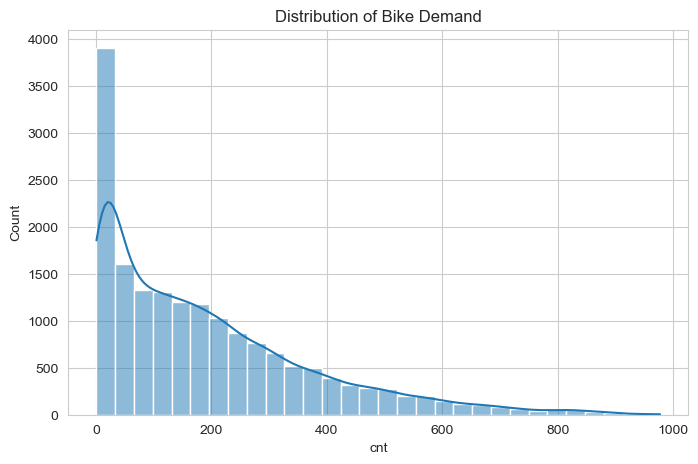

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cnt"], bins=30, kde=True)
plt.title("Distribution of Bike Demand")
plt.show()

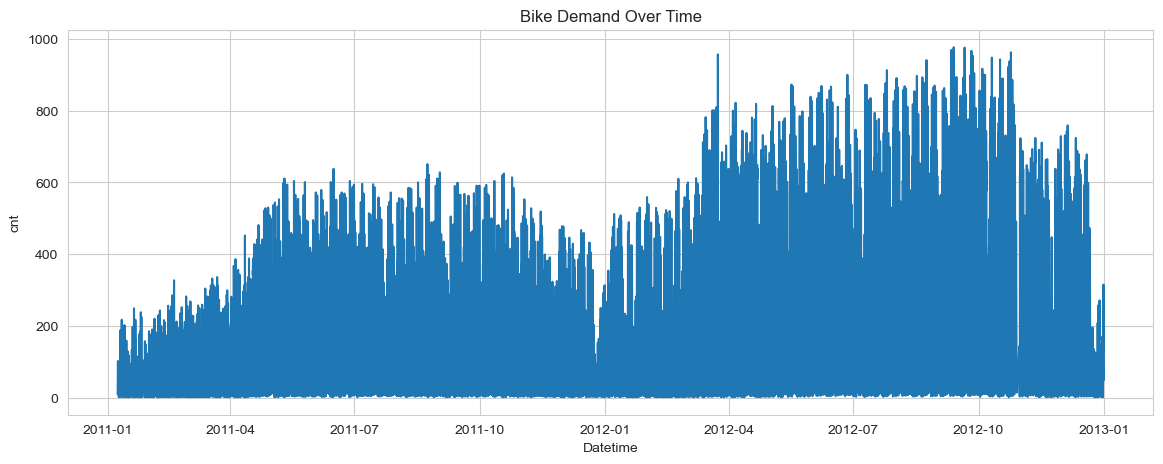

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["cnt"])
plt.title("Bike Demand Over Time")
plt.xlabel("Datetime")
plt.ylabel("cnt")
plt.show()

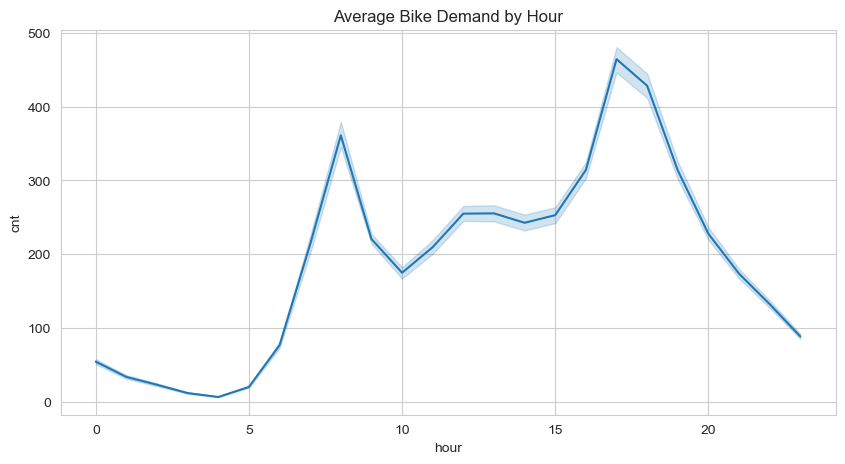

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x="hour", y="cnt", estimator="mean")
plt.title("Average Bike Demand by Hour")
plt.show()

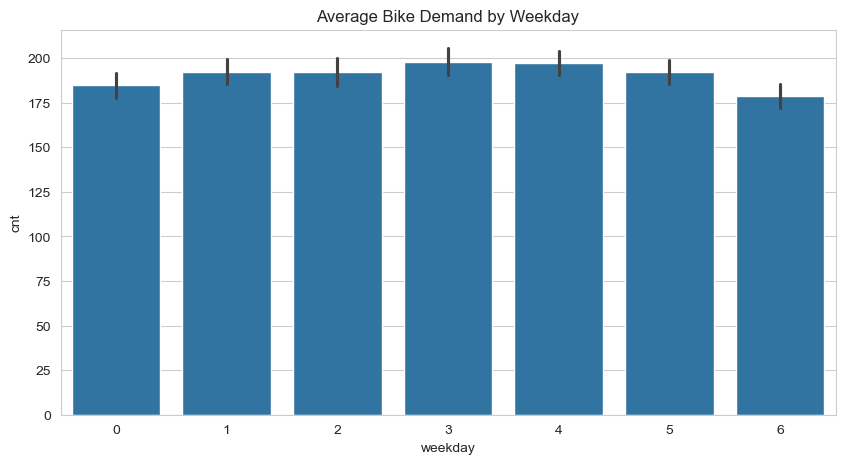

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="weekday", y="cnt")
plt.title("Average Bike Demand by Weekday")
plt.show()

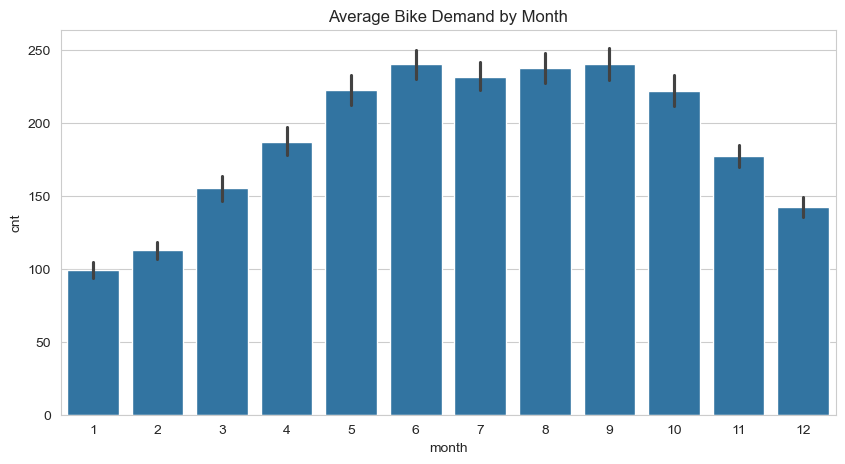

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="month", y="cnt")
plt.title("Average Bike Demand by Month")
plt.show()

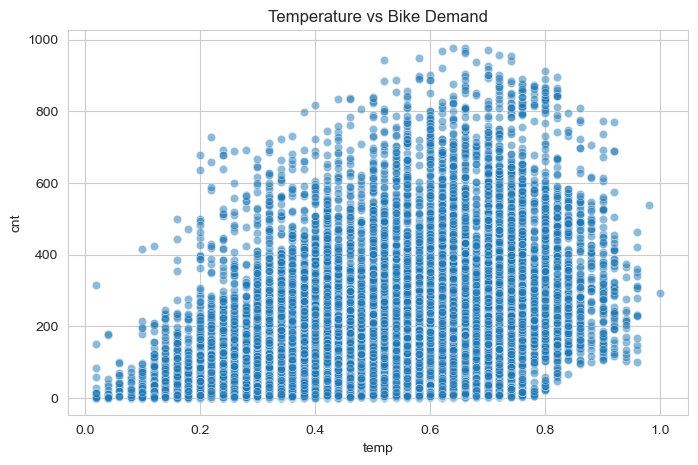

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="temp", y="cnt", alpha=0.5)
plt.title("Temperature vs Bike Demand")
plt.show()

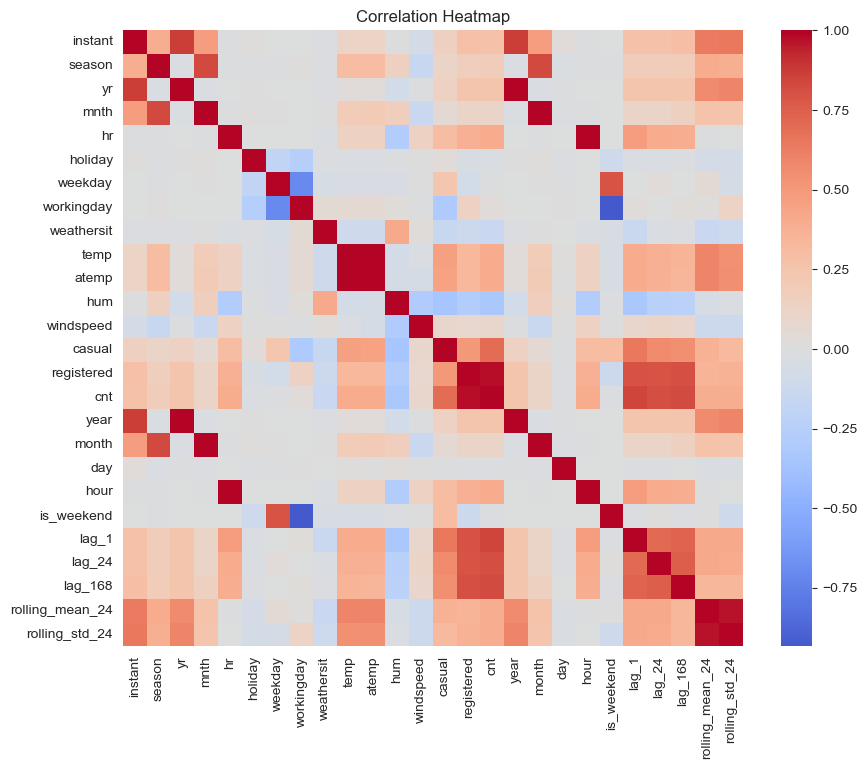

In [11]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Modeling

In [12]:
features = [
    "season", "yr", "mnth", "holiday", "workingday", "weathersit",
    "temp", "atemp", "hum", "windspeed",
    "year", "month", "day", "hour", "weekday", "is_weekend",
    "lag_1", "lag_24", "lag_168",
    "rolling_mean_24", "rolling_std_24"
]

target = "cnt"

X = df[features]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(X_train.shape, X_test.shape)

(13768, 21) (3443, 21)


In [13]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R2:", r2_score(y_test, baseline_pred))

Baseline MAE: 60.96343982773686
Baseline RMSE: 89.15050990830264
Baseline R2: 0.8355358864651645


In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest MAE: 33.93434946247458
Random Forest RMSE: 57.69807815798416
Random Forest R2: 0.9311115868613259


In [15]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

print("Gradient Boosting MAE:", mean_absolute_error(y_test, gbr_pred))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gbr_pred)))
print("Gradient Boosting R2:", r2_score(y_test, gbr_pred))

Gradient Boosting MAE: 34.135807844585884
Gradient Boosting RMSE: 52.79426651854018
Gradient Boosting R2: 0.9423237512115528


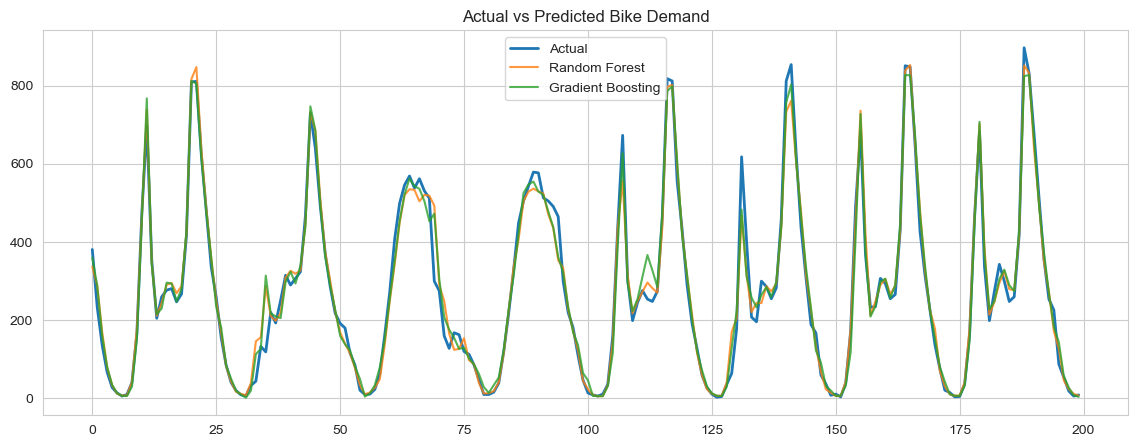

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:200], label="Actual", linewidth=2)
plt.plot(rf_pred[:200], label="Random Forest", alpha=0.8)
plt.plot(gbr_pred[:200], label="Gradient Boosting", alpha=0.8)
plt.legend()
plt.title("Actual vs Predicted Bike Demand")
plt.show()

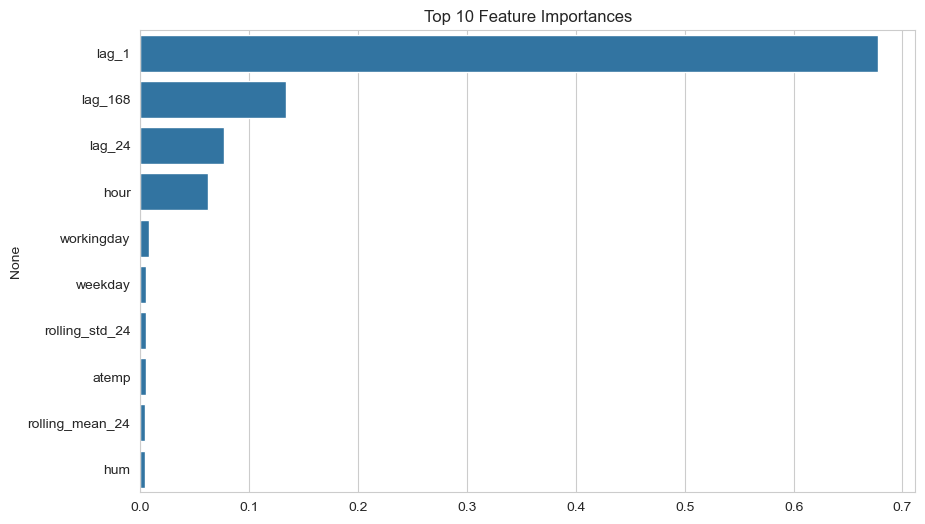

In [17]:
feature_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values[:10], y=feature_importance.index[:10])
plt.title("Top 10 Feature Importances")
plt.show()

## Key Takeaways

- Bike demand shows strong hourly and weekly seasonality.
- Lag-based and rolling features improved forecasting performance over the baseline model.
- Tree-based ensemble models clearly outperformed linear regression on this task.
- Gradient Boosting achieved the best overall performance with an R² of 0.9423 and an RMSE of 52.79.
- Time-aware validation was important for producing a realistic evaluation of forecasting performance.